In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import sys, pathlib

# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: C:\Users\f.spreemann\qecsim-work


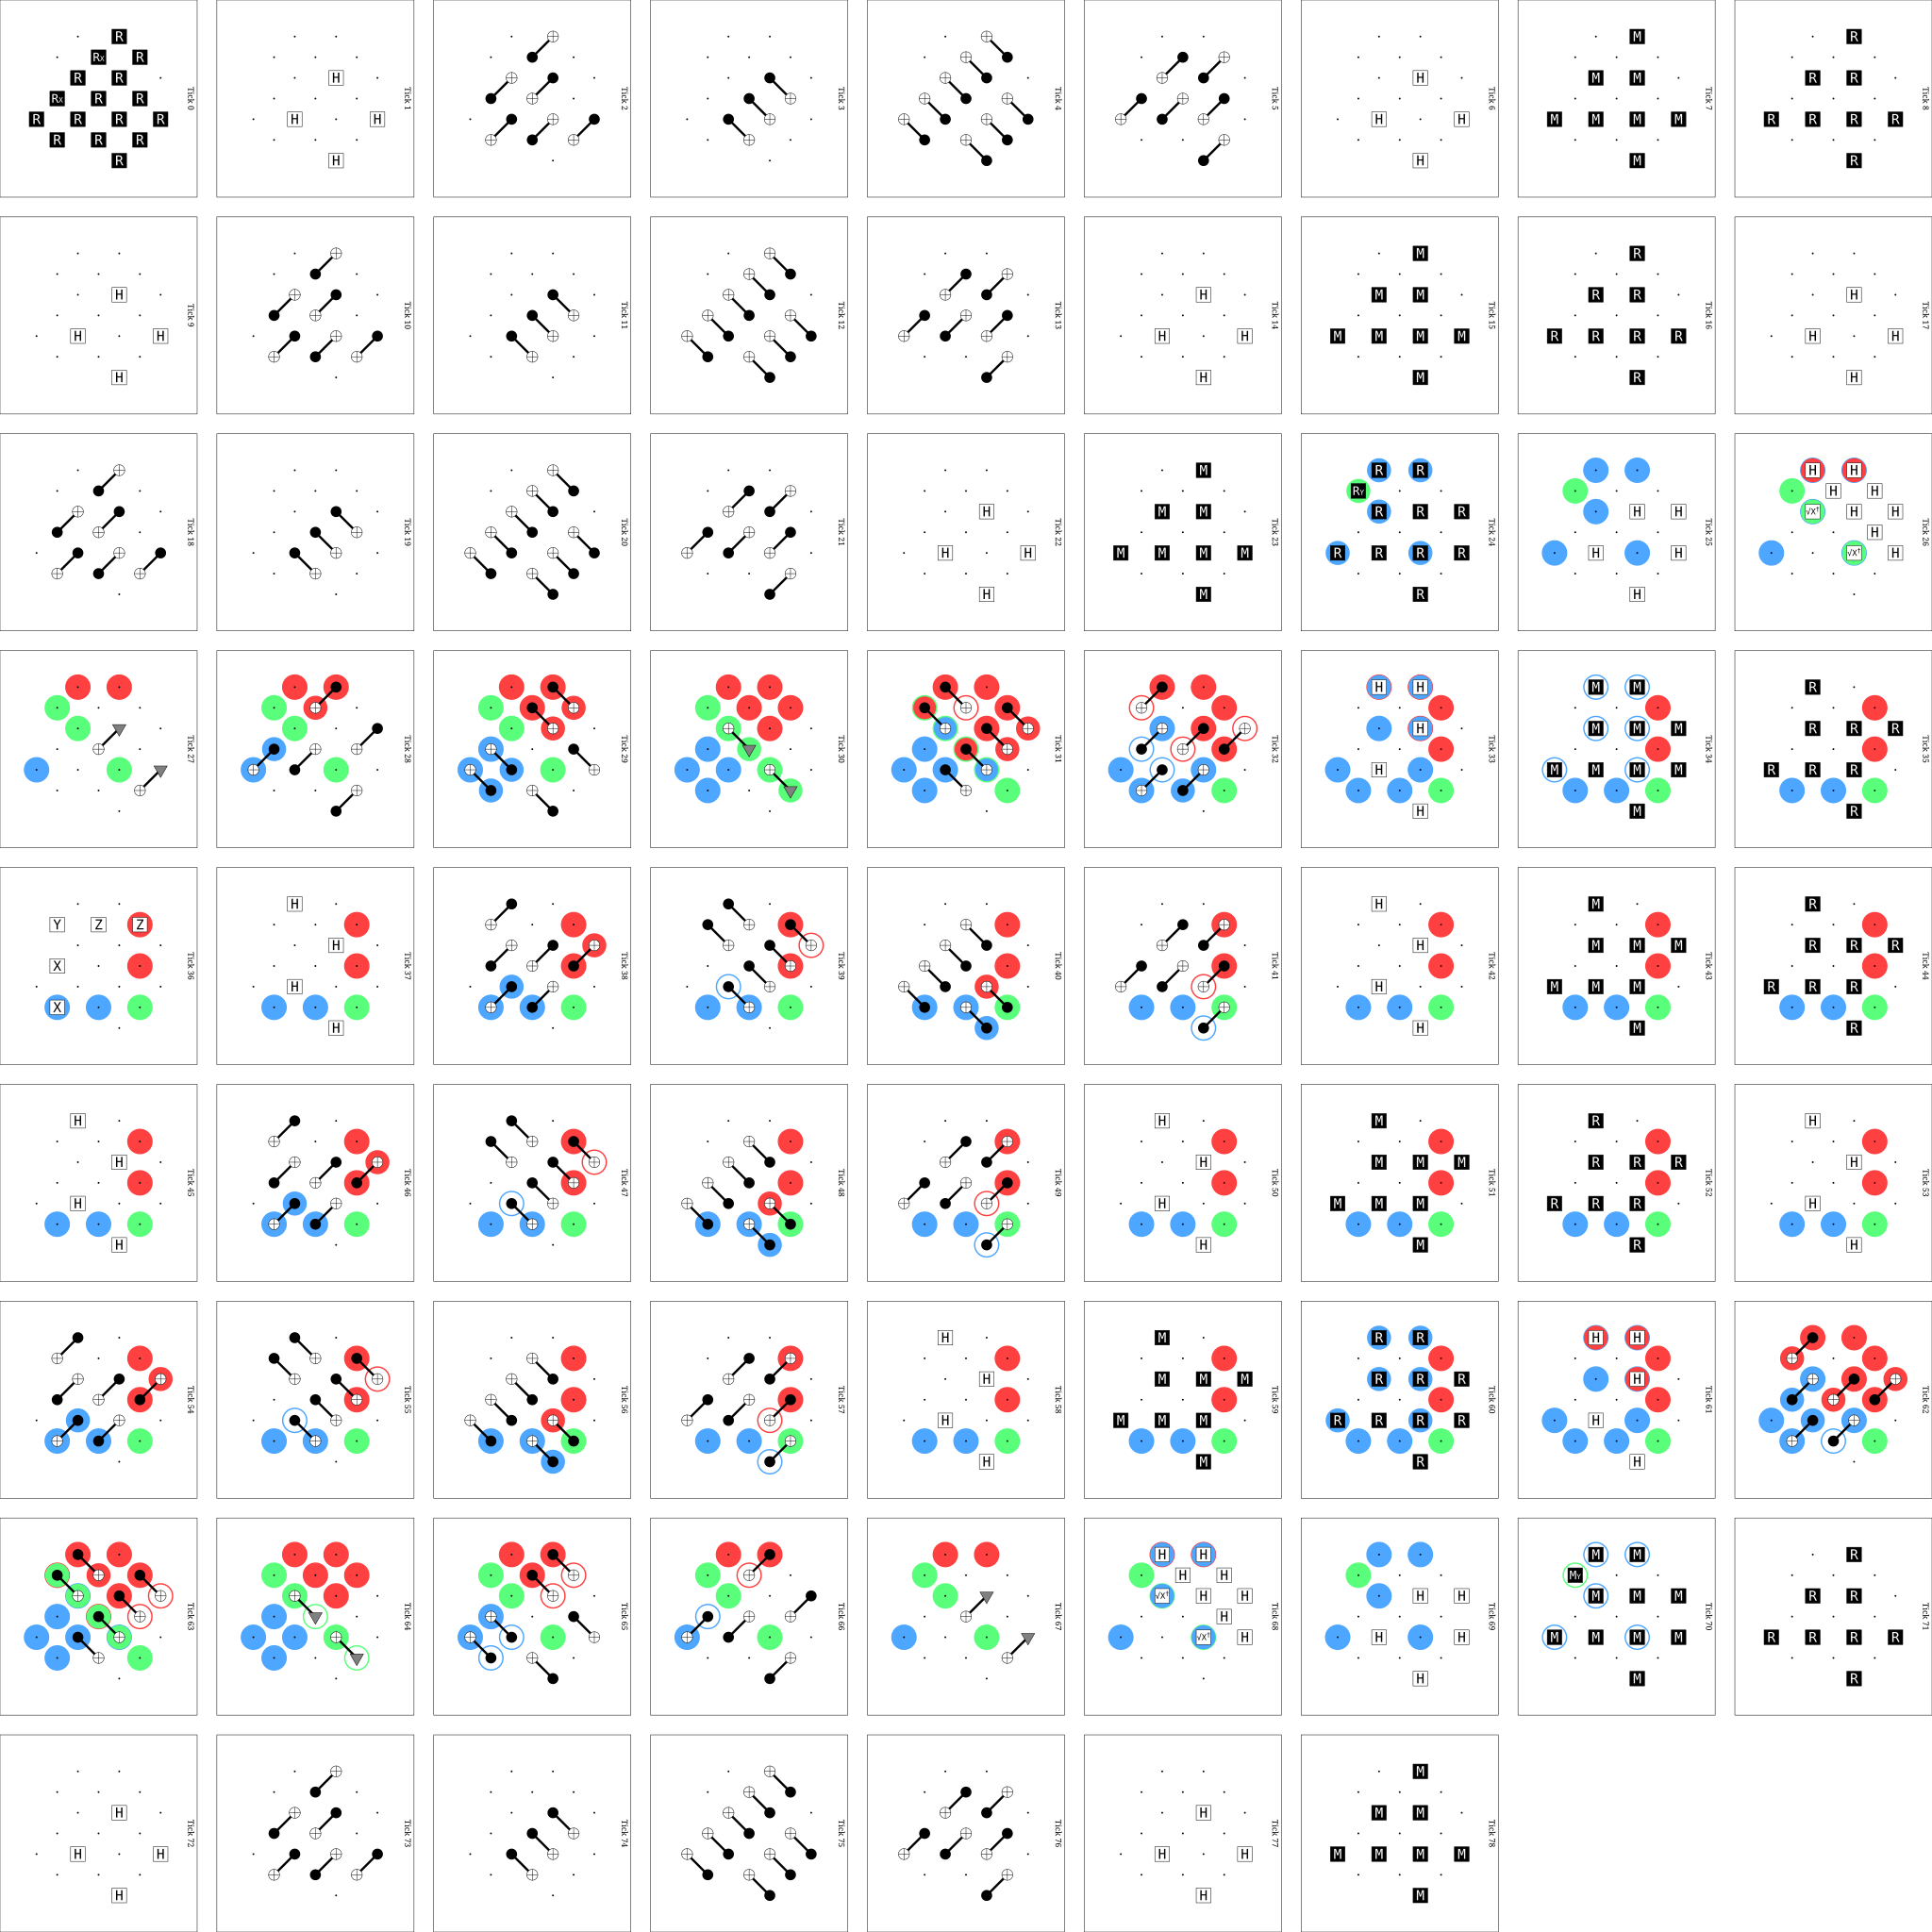

In [53]:
from src.codes.surface_code_rotated.builder import SurfaceBuilder

build = SurfaceBuilder(distance=3, state_init="-i", log_obs="Y")

circuit = build.build_circuit()

circuit.diagram("detslice-with-ops-svg", filter_coords="L0")

In [54]:
from src.codes.lattice_surgery.builder import SurgeryBuilder

**TODO**

- Current Y Observables do not seem to cahnge the measurement outcome when flipped which makes no sense
    - Happens for fault tolerant as well as non fualt tolerant procedure
- Implmented resets on all qubits in non-ft mode but thats total bullshit, makes no sense

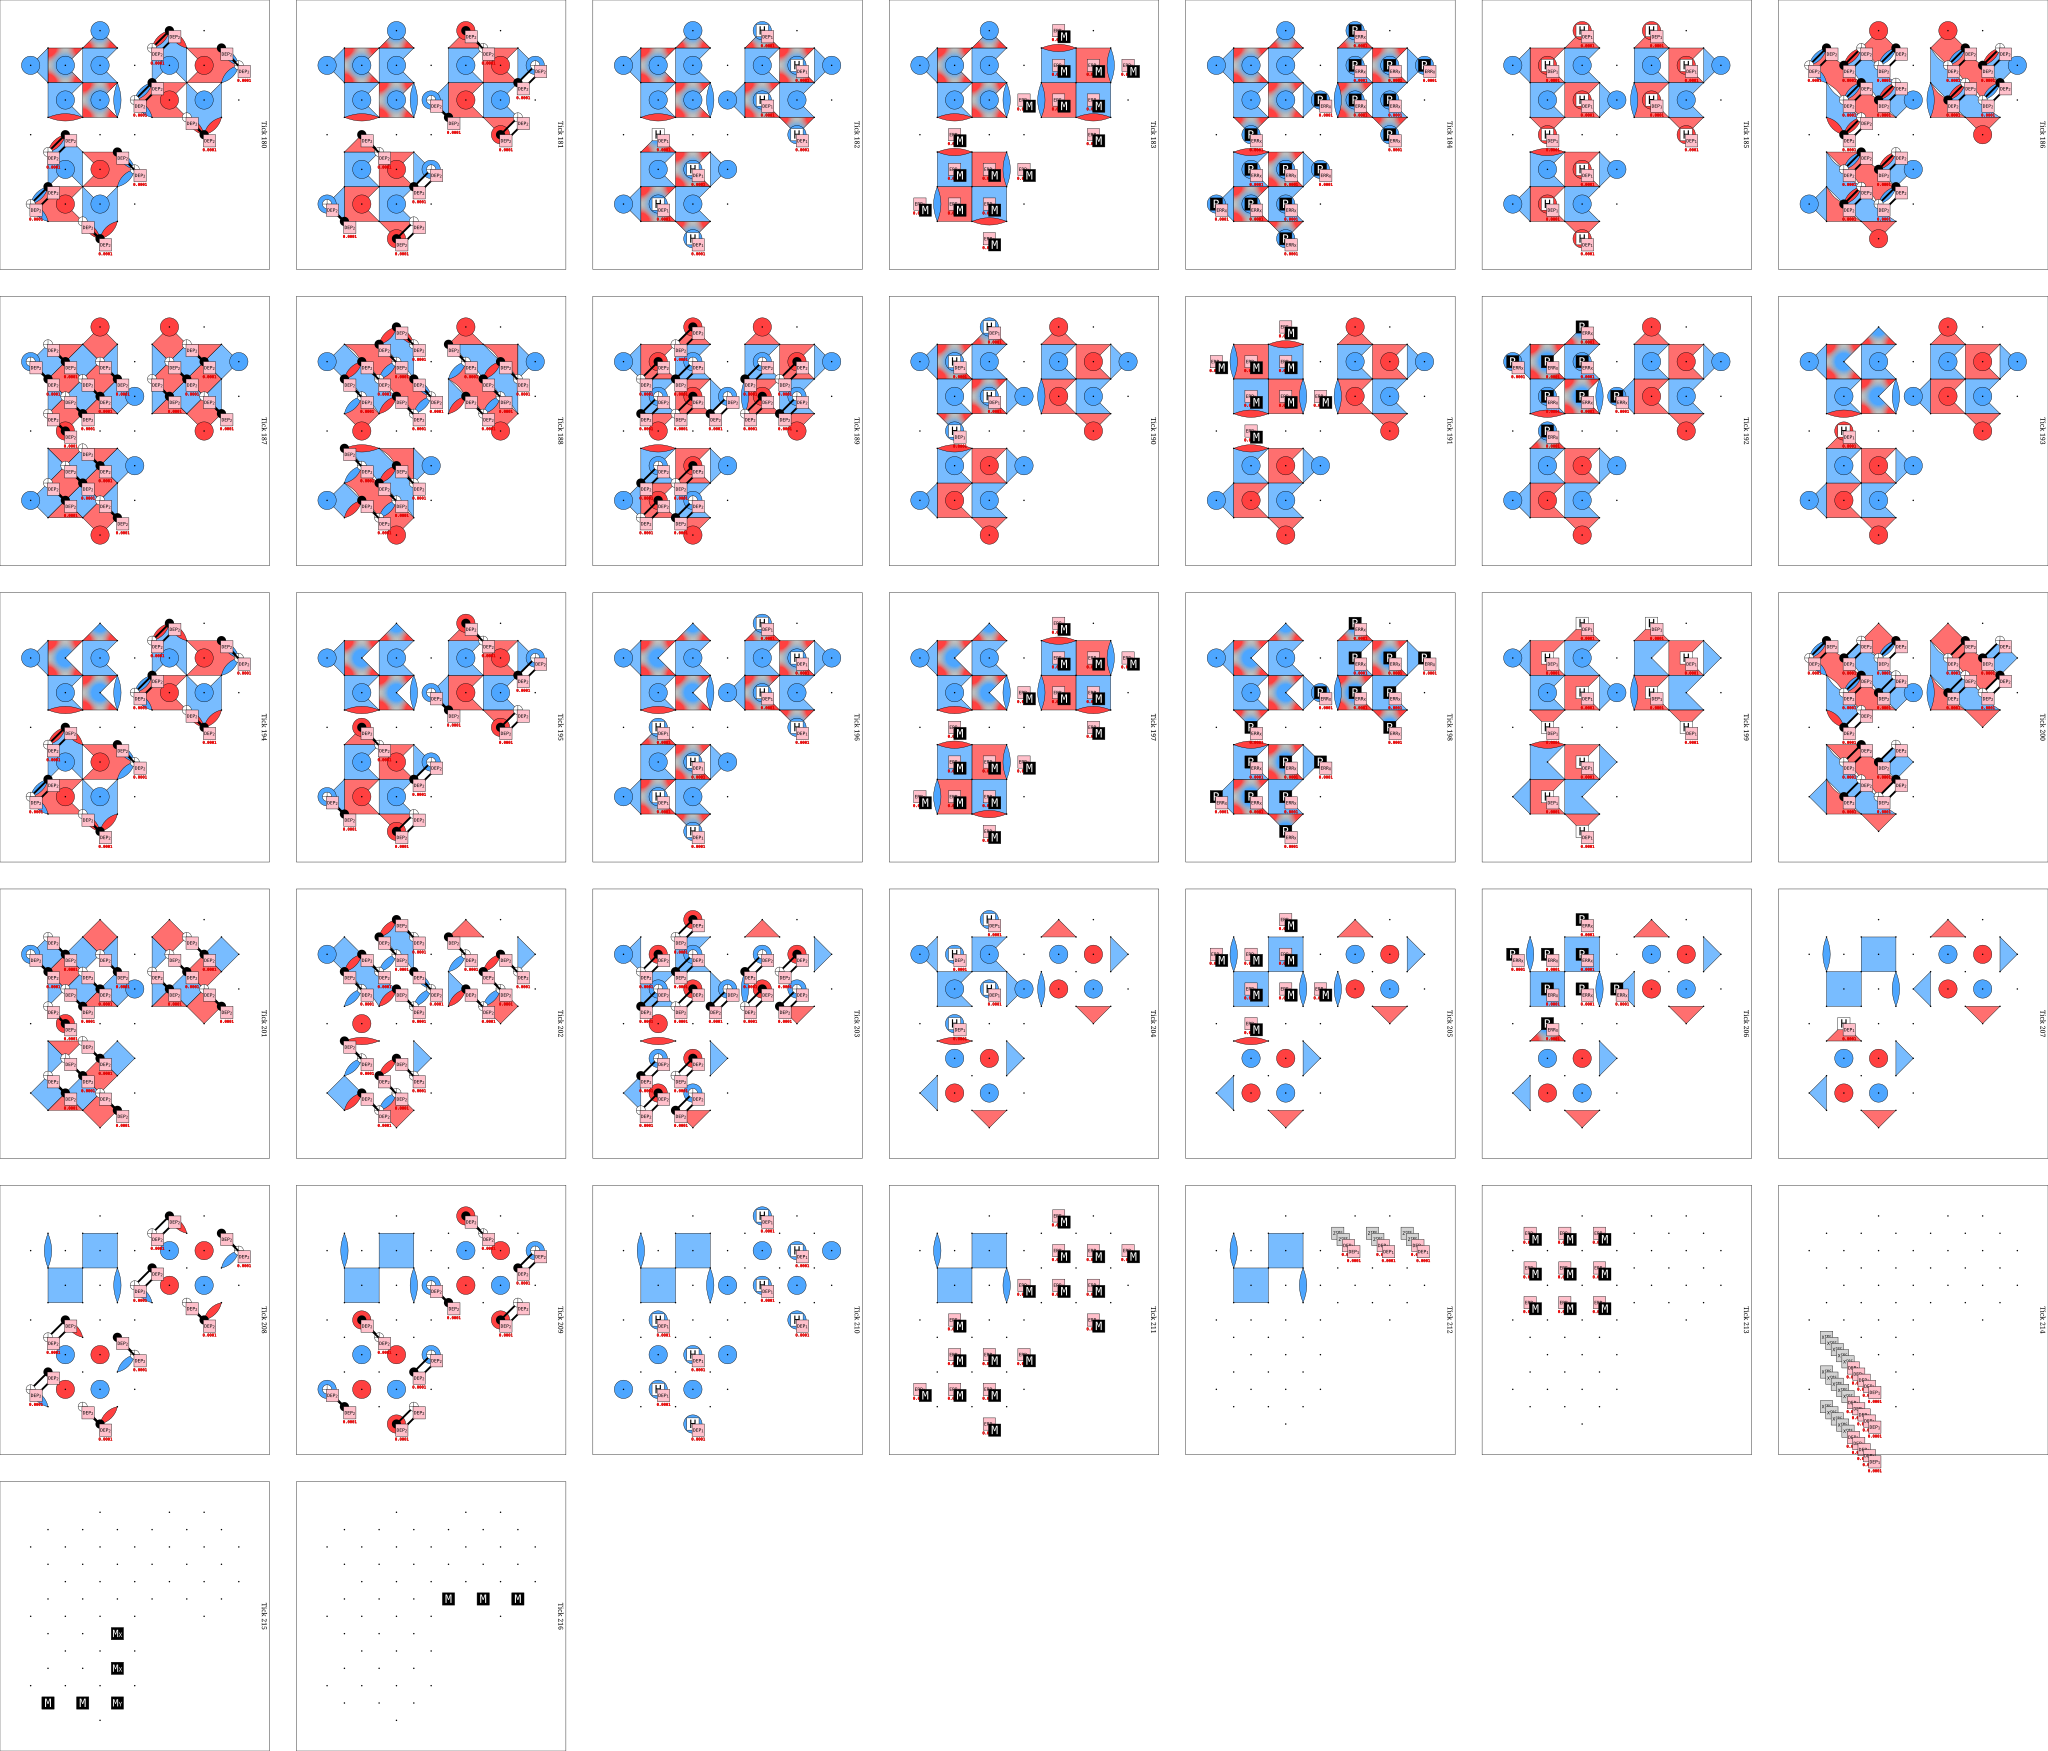

In [93]:
from src.core.data_models import NoiseParameters

noise = 1e-4

noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)


test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="Y+", target_state_init="X+",
                                      control_measure_basis="Y", target_measure_basis="I", noise= noise_class)

test_surgery_circuit = test_surgery_builder.build_circuit()
test_measurement_rec = test_surgery_builder.get_logical_meas_rec(observable_index=0)

test_surgery_circuit.diagram("detslice-with-ops-svg", tick = range(180, 250))

In [73]:
import numpy as np
from src.core.data_models import NoiseParameters

noise = 1e-4

noise_class = NoiseParameters(before_round_depol=noise,
                              before_m_flip_prob=noise,
                              after_r_flip=noise,
                              after_c_depol_prob=noise,
                              after_c_pauli_channel_prob=noise)

test_surgery_builder = SurgeryBuilder(distance=3, control_state_init="Z0", target_state_init="Y+",
                                      control_measure_basis="I", target_measure_basis="Y",
                                      noise= noise_class
                                      )
test_surgery_circuit = test_surgery_builder.build_circuit()
test_measurement_rec = test_surgery_builder.get_logical_meas_rec(observable_index=0)

sampler = test_surgery_circuit.compile_sampler()
results_samples = sampler.sample(shots=1000)

final_res = 0
for i in test_measurement_rec:
    final_res ^= results_samples[:, i].astype(np.int8)
print(final_res)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 